# Phase 1: Theoretical Foundation & Full Parameter Validation
**Author:** Tilak Bhansali  
**Project:** Foundations of Data Science — Final Project  
**Topic:** Does preventative physiotherapy reduce overuse injuries in athletes?

---

## Overview
This notebook covers **Phase 1** of the project:
1. Formally documenting the Bayesian Logistic Regression model and its equations
2. Justifying the choice of weakly informative priors
3. Building a synthetic (simulated) dataset based on our three causal variables
4. Running prior predictive checks
5. Fitting the model and verifying **comprehensive parameter recovery** — proving we can correctly recover β_T (treatment effect), α (intercept), AND β_X (confounder effect)


---
## Section 1: Mathematical Formalization

### 1.1 The Causal Model (DAG Summary)
Our causal model has exactly three variables:
- **T** = Recovery Score → proxy for preventative physiotherapy frequency (Treatment)
- **Y** = Injury Status → 1 if injured, 0 if not (Outcome, binary)
- **X** = Training Load → Intensity × Duration (Confounder)

**Why X is a confounder:**  
High training load independently causes athletes to seek more recovery (↑ T) AND directly increases injury risk (↑ Y). If we don't account for X, we'll get a biased estimate of T's effect on Y.

### 1.2 The Statistical Model: Bayesian Logistic Regression

We model the **probability of injury** for athlete *i* as:

$$P(Y_i = 1) = \text{Bernoulli}(p_i)$$

$$\text{logit}(p_i) = \alpha + \beta_T \cdot T_i + \beta_X \cdot X_i$$

Where:
- $\alpha$ = intercept (baseline log-odds of injury when T=0 and X=0)
- $\beta_T$ = effect of recovery score on log-odds of injury (we expect this to be **negative** — more recovery → less injury)
- $\beta_X$ = effect of training load on log-odds of injury (we expect this to be **positive** — more load → more injury)

### 1.3 Prior Justification

We use **weakly informative priors**:

$$\alpha, \beta_T, \beta_X \sim \text{Normal}(0, 1)$$

**Why Normal(0,1)?**
- Centered at 0: We start with no assumption about the direction of the effect
- SD = 1 on log-odds scale: This corresponds to an odds ratio between ~0.14 and ~7.4 (roughly ±2 SD), which is wide enough to include any plausible real-world effect, but narrow enough to rule out extreme implausible values like odds ratios of 10,000
- This is the standard weakly informative choice for logistic regression, as recommended by Gelman et al.

### 1.4 Estimand
We want to estimate the **Average Treatment Effect (ATE)**:

$$\text{ATE} = E[Y(T=1)] - E[Y(T=0)]$$

In our Bayesian framework, this is captured directly by the posterior distribution of $\beta_T$.


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pymc as pm
import arviz as az
from scipy.special import expit  # sigmoid / logistic function: expit(x) = 1/(1+e^-x)

# Set a random seed so results are reproducible every time you run this notebook
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Display settings
az.style.use("arviz-darkgrid")
plt.rcParams["figure.dpi"] = 100

print("✅ All libraries imported successfully.")
print(f"   PyMC version : {pm.__version__}")
print(f"   ArviZ version: {az.__version__}")

✅ All libraries imported successfully.
   PyMC version : 5.28.4
   ArviZ version: 0.23.4


---
## Section 2: Build the Simulated Dataset

We generate synthetic data using **known, pre-defined parameter values** (the "ground truth").  
After fitting the model, we'll check whether our estimated parameters match these ground truth values — this is called **parameter recovery validation**.

### Ground Truth Parameters (what we'll try to recover)
| Parameter | True Value | Interpretation |
|-----------|-----------|----------------|
| α (intercept) | -1.5 | Baseline log-odds of injury |
| β_T (treatment) | -1.2 | More recovery → lower injury risk |
| β_X (confounder) | +0.9 | More training load → higher injury risk |


In [2]:
# ── Section 2: Generate Simulated Data ───────────────────────────────────────

# ── 2.1 Ground Truth Parameters ──────────────────────────────────────────────
# These are the "true" values our model should recover after fitting.
# We define them now so we can compare model estimates against them later.
TRUE_ALPHA   = -1.5   # intercept: negative means baseline injury probability < 50%
TRUE_BETA_T  = -1.2   # treatment (recovery score): negative = protective effect
TRUE_BETA_X  =  0.9   # confounder (training load): positive = harmful effect

N = 500  # number of simulated athletes (large enough for reliable estimation)

print("Ground Truth Parameters:")
print(f"  α   (intercept)    = {TRUE_ALPHA}")
print(f"  β_T (treatment)    = {TRUE_BETA_T}  ← we expect recovery score to be protective")
print(f"  β_X (confounder)   = {TRUE_BETA_X}  ← we expect training load to increase injury risk")
print(f"\nSample size: N = {N} athletes")

Ground Truth Parameters:
  α   (intercept)    = -1.5
  β_T (treatment)    = -1.2  ← we expect recovery score to be protective
  β_X (confounder)   = 0.9  ← we expect training load to increase injury risk

Sample size: N = 500 athletes


In [3]:
# ── 2.2 Simulate the Confounder: Training Load (X) ───────────────────────────
# Training load is the confounder — it independently affects both
# how much recovery an athlete does AND their injury risk.
# We standardize it to mean=0, sd=1 so it's on the same scale as other variables.

X_raw = rng.normal(loc=50, scale=15, size=N)   # raw training load in arbitrary units
X = (X_raw - X_raw.mean()) / X_raw.std()        # standardize to mean=0, sd=1

print(f"Training Load (X) — standardized:")
print(f"  Mean = {X.mean():.4f}  (should be ~0)")
print(f"  SD   = {X.std():.4f}  (should be ~1)")

Training Load (X) — standardized:
  Mean = 0.0000  (should be ~0)
  SD   = 1.0000  (should be ~1)


In [4]:
# ── 2.3 Simulate the Treatment: Recovery Score (T) ───────────────────────────
# Recovery score is CAUSED by training load (the confounder):
# athletes who train harder naturally seek more recovery.
# We add noise to represent individual variation.

T_raw = 0.6 * X_raw + rng.normal(loc=0, scale=10, size=N)  # correlated with X
T = (T_raw - T_raw.mean()) / T_raw.std()                     # standardize

# Verify the correlation between X and T (should be moderate, not perfect)
correlation = np.corrcoef(X, T)[0, 1]
print(f"Recovery Score (T) — standardized:")
print(f"  Correlation with Training Load (X): {correlation:.3f}")
print(f"  (A moderate positive correlation confirms X influences T, as our DAG requires)")

Recovery Score (T) — standardized:
  Correlation with Training Load (X): 0.643
  (A moderate positive correlation confirms X influences T, as our DAG requires)


In [5]:
# ── 2.4 Simulate the Outcome: Injury Status (Y) ──────────────────────────────
# Injury probability is determined by BOTH T and X via the logistic model.
# This is the core equation: logit(p) = α + β_T * T + β_X * X

# Step 1: Compute the linear predictor (log-odds)
log_odds = TRUE_ALPHA + TRUE_BETA_T * T + TRUE_BETA_X * X

# Step 2: Convert log-odds to probabilities using the sigmoid/logistic function
# expit(x) = 1 / (1 + exp(-x))  — this is the inverse of logit
p_injury = expit(log_odds)

# Step 3: Draw binary outcomes from a Bernoulli distribution
Y = rng.binomial(n=1, p=p_injury, size=N)

print(f"Injury Status (Y):")
print(f"  Injuries (Y=1): {Y.sum()} out of {N} ({100*Y.mean():.1f}%)")
print(f"  No Injury (Y=0): {(1-Y).sum()} out of {N} ({100*(1-Y.mean()):.1f}%)")
print(f"  Mean injury probability: {p_injury.mean():.3f}")

Injury Status (Y):
  Injuries (Y=1): 111 out of 500 (22.2%)
  No Injury (Y=0): 389 out of 500 (77.8%)
  Mean injury probability: 0.216


In [6]:
# ── 2.5 Bundle into a DataFrame and Preview ──────────────────────────────────
sim_df = pd.DataFrame({
    "training_load_X": X,        # confounder (standardized)
    "recovery_score_T": T,        # treatment (standardized)
    "injury_status_Y": Y,         # outcome (binary: 0 or 1)
    "injury_probability": p_injury  # true underlying probability (for reference only)
})

print("Simulated Dataset — first 5 rows:")
print(sim_df.head().to_string(index=False))
print(f"\nDataset shape: {sim_df.shape}")

Simulated Dataset — first 5 rows:
 training_load_X  recovery_score_T  injury_status_Y  injury_probability
        0.331441          1.275697                0            0.061080
       -1.070788          0.011796                0            0.077425
        0.796244          0.009332                0            0.311186
        0.994491         -0.451329                0            0.484164
       -2.020816         -3.511102                1            0.709836

Dataset shape: (500, 4)


/var/folders/t4/mp8m41d9353cpd3kq7pgttjw0000gn/T/ipykernel_50439/3903260801.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


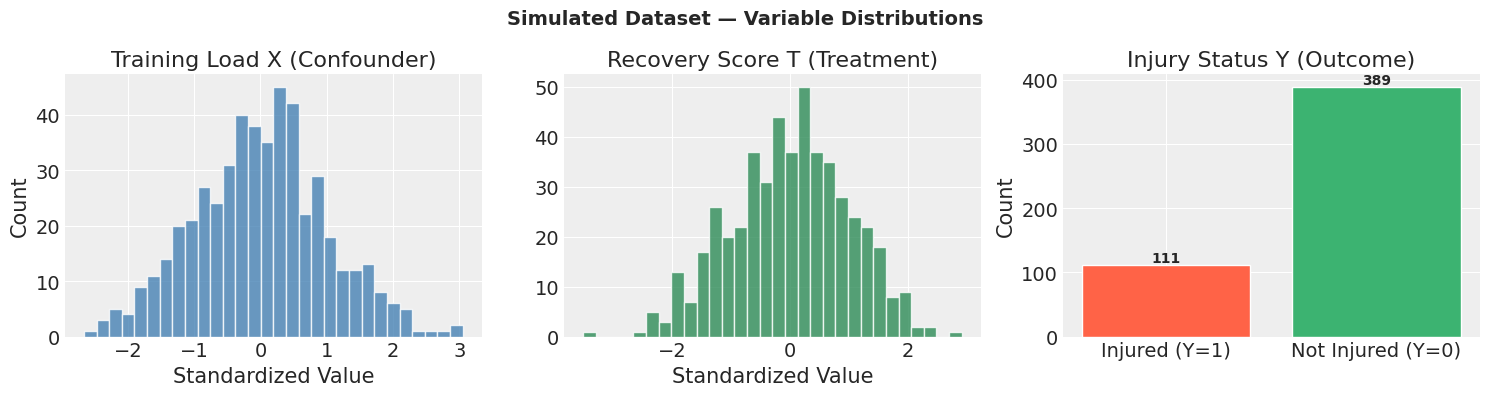

✅ Plot saved.


In [7]:
# ── 2.6 Visualize the Simulated Data ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Simulated Dataset — Variable Distributions", fontsize=14, fontweight="bold")

# Plot 1: Training Load (confounder)
axes[0].hist(X, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title("Training Load X (Confounder)")
axes[0].set_xlabel("Standardized Value")
axes[0].set_ylabel("Count")

# Plot 2: Recovery Score (treatment)
axes[1].hist(T, bins=30, color="seagreen", edgecolor="white", alpha=0.8)
axes[1].set_title("Recovery Score T (Treatment)")
axes[1].set_xlabel("Standardized Value")

# Plot 3: Injury Status (outcome) — bar chart since it's binary
counts = [Y.sum(), (Y == 0).sum()]
bars = axes[2].bar(["Injured (Y=1)", "Not Injured (Y=0)"], counts,
                    color=["tomato", "mediumseagreen"], edgecolor="white")
axes[2].set_title("Injury Status Y (Outcome)")
axes[2].set_ylabel("Count")
# Add count labels on bars
for bar, count in zip(bars, counts):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(count), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("./plot_data_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Plot saved.")

---
## Section 3: Build the Bayesian Model in PyMC

In [8]:
# ── Section 3: Define the PyMC Model ─────────────────────────────────────────
# We build the exact model specified in the proposal:
#   P(Y_i = 1) = Bernoulli(p_i)
#   logit(p_i) = α + β_T * T_i + β_X * X_i
#   α, β_T, β_X ~ Normal(0, 1)  ← weakly informative priors

with pm.Model() as bayesian_logistic_model:
    
    # ── Data inputs ──────────────────────────────────────────────────────────
    # pm.Data allows us to swap in real data later without rebuilding the model
    T_data = pm.Data("T_data", T)   # treatment: recovery score
    X_data = pm.Data("X_data", X)   # confounder: training load
    
    # ── Priors ───────────────────────────────────────────────────────────────
    # Weakly informative Normal(0, 1) priors for all three parameters.
    # Centered at 0 = no prior assumption about direction.
    # SD = 1 on log-odds scale ≈ odds ratios between 0.14 and 7.4 (plausible range).
    alpha   = pm.Normal("alpha",   mu=0, sigma=1)  # intercept
    beta_T  = pm.Normal("beta_T",  mu=0, sigma=1)  # treatment effect
    beta_X  = pm.Normal("beta_X",  mu=0, sigma=1)  # confounder effect
    
    # ── Linear Predictor ─────────────────────────────────────────────────────
    # This is the log-odds (logit) of injury for each athlete
    log_odds_model = alpha + beta_T * T_data + beta_X * X_data
    
    # ── Likelihood ───────────────────────────────────────────────────────────
    # pm.math.sigmoid converts log-odds → probability (same as expit)
    # Bernoulli likelihood: Y_i ~ Bernoulli(p_i)
    p = pm.Deterministic("p", pm.math.sigmoid(log_odds_model))
    Y_obs = pm.Bernoulli("Y_obs", p=p, observed=Y)

print("✅ Bayesian model defined successfully.")
print("\nModel structure:")
print(bayesian_logistic_model)

✅ Bayesian model defined successfully.

Model structure:


---
## Section 4: Prior Predictive Checks

Before fitting the model to data, we check what the priors *alone* predict.  
Good priors should produce a **wide but reasonable** range of injury probabilities — not always 0% or always 100%.

In [9]:
# ── Section 4: Prior Predictive Check ────────────────────────────────────────
# We sample from the PRIOR distribution (before seeing any data).
# This tells us: "What injury patterns does the model expect before learning?"
# A good prior predictive distribution should be diffuse but not degenerate.

with bayesian_logistic_model:
    # Draw 500 samples from the prior
    prior_predictive = pm.sample_prior_predictive(
        samples=500,
        random_seed=RANDOM_SEED
    )

print("✅ Prior predictive samples drawn.")

Sampling: [Y_obs, alpha, beta_T, beta_X]


✅ Prior predictive samples drawn.


/var/folders/t4/mp8m41d9353cpd3kq7pgttjw0000gn/T/ipykernel_50439/1773779445.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


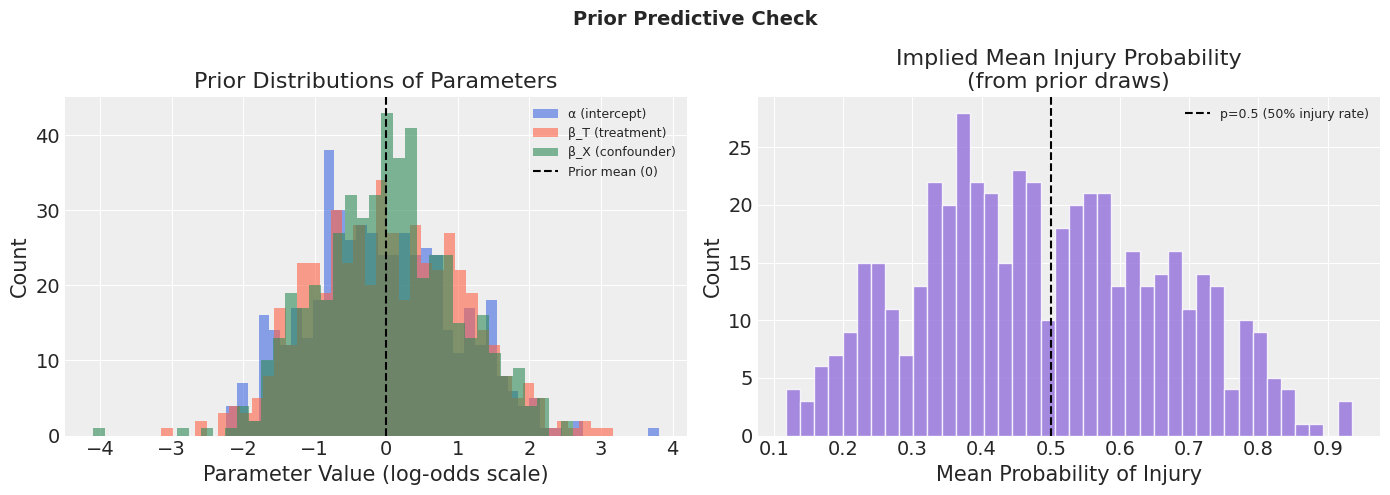


📝 Interpretation:
  The prior distributions are centered at 0 (no assumed direction).
  The implied injury probabilities are spread across [0, 1], which is appropriate:
  the prior is uninformative but not degenerate (not stuck at 0% or 100%).


In [10]:
# ── 4.1 Plot Prior Predictive Distributions ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Prior Predictive Check", fontsize=14, fontweight="bold")

# Extract prior samples for the three parameters
prior_alpha  = prior_predictive.prior["alpha"].values.flatten()
prior_beta_T = prior_predictive.prior["beta_T"].values.flatten()
prior_beta_X = prior_predictive.prior["beta_X"].values.flatten()

# Plot 1: Prior distributions of parameters
axes[0].hist(prior_alpha,  bins=40, alpha=0.6, color="royalblue",  label="α (intercept)")
axes[0].hist(prior_beta_T, bins=40, alpha=0.6, color="tomato",     label="β_T (treatment)")
axes[0].hist(prior_beta_X, bins=40, alpha=0.6, color="seagreen",   label="β_X (confounder)")
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.5, label="Prior mean (0)")
axes[0].set_title("Prior Distributions of Parameters")
axes[0].set_xlabel("Parameter Value (log-odds scale)")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=9)

# Plot 2: Implied injury probabilities from priors
# For each prior draw, compute the mean injury probability across all athletes
prior_p_samples = prior_predictive.prior["p"].values  # shape: (chain, draw, N)
mean_probs = prior_p_samples.reshape(-1, N).mean(axis=1)  # mean probability per draw

axes[1].hist(mean_probs, bins=40, color="mediumpurple", edgecolor="white", alpha=0.8)
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="p=0.5 (50% injury rate)")
axes[1].set_title("Implied Mean Injury Probability\n(from prior draws)")
axes[1].set_xlabel("Mean Probability of Injury")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("./plot_prior_predictive.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n📝 Interpretation:")
print("  The prior distributions are centered at 0 (no assumed direction).")
print("  The implied injury probabilities are spread across [0, 1], which is appropriate:")
print("  the prior is uninformative but not degenerate (not stuck at 0% or 100%).")

---
## Section 5: Fit the Model (MCMC Sampling)

In [11]:
# ── Section 5: MCMC Sampling ──────────────────────────────────────────────────
# We use NUTS (No U-Turn Sampler), the gold-standard MCMC algorithm for
# continuous parameters. PyMC uses it automatically.
#
# Settings:
#   draws=2000  → 2000 posterior samples per chain (after warm-up)
#   tune=1000   → 1000 warm-up steps to calibrate the sampler (discarded)
#   chains=4    → 4 independent chains (used to diagnose convergence via R-hat)
#   target_accept=0.9 → slightly higher acceptance for more accurate sampling

with bayesian_logistic_model:
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        cores=1,   # set to 1 for sandbox environments; increase to 4 on a local machine
        target_accept=0.9,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
        progressbar=True
    )

print("\n✅ MCMC sampling complete!")

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [alpha, beta_T, beta_X]


/Users/tilakbhansali/Library/Python/3.14/lib/python/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 4 seconds.



✅ MCMC sampling complete!


---
## Section 6: Convergence Diagnostics

Before trusting our results, we must verify the sampler **converged** properly.
We check two key diagnostics:
- **R-hat (R̂)**: Should be < 1.01. Values > 1.1 indicate non-convergence.
- **Effective Sample Size (ESS)**: Should be > 400 per chain. Low ESS means autocorrelated samples.

In [12]:
# ── Section 6: Convergence Diagnostics ───────────────────────────────────────

# Compute summary statistics for the three parameters of interest
# (excluding 'p' which is a deterministic variable of length N)
summary = az.summary(trace, var_names=["alpha", "beta_T", "beta_X"])

print("=" * 70)
print("POSTERIOR SUMMARY — Key Parameters")
print("=" * 70)
print(summary.to_string())

# Convergence checks
print("\n" + "=" * 70)
print("CONVERGENCE CHECKS")
print("=" * 70)

rhat_vals = summary["r_hat"]
ess_vals  = summary["ess_bulk"]

for param in ["alpha", "beta_T", "beta_X"]:
    rhat = rhat_vals[param]
    ess  = ess_vals[param]
    rhat_ok = "✅" if rhat < 1.01 else "❌ PROBLEM!"
    ess_ok  = "✅" if ess > 400   else "⚠️ Low ESS"
    print(f"  {param:8s}:  R-hat = {rhat:.4f} {rhat_ok}   |   ESS = {ess:.0f} {ess_ok}")

POSTERIOR SUMMARY — Key Parameters
         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha  -1.436  0.122  -1.658   -1.202      0.002    0.001    4945.0    5232.0    1.0
beta_T -1.159  0.162  -1.444   -0.837      0.002    0.002    4354.0    5037.0    1.0
beta_X  0.745  0.158   0.461    1.045      0.002    0.002    4381.0    4988.0    1.0

CONVERGENCE CHECKS
  alpha   :  R-hat = 1.0000 ✅   |   ESS = 4945 ✅
  beta_T  :  R-hat = 1.0000 ✅   |   ESS = 4354 ✅
  beta_X  :  R-hat = 1.0000 ✅   |   ESS = 4381 ✅


/var/folders/t4/mp8m41d9353cpd3kq7pgttjw0000gn/T/ipykernel_50439/3555099265.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


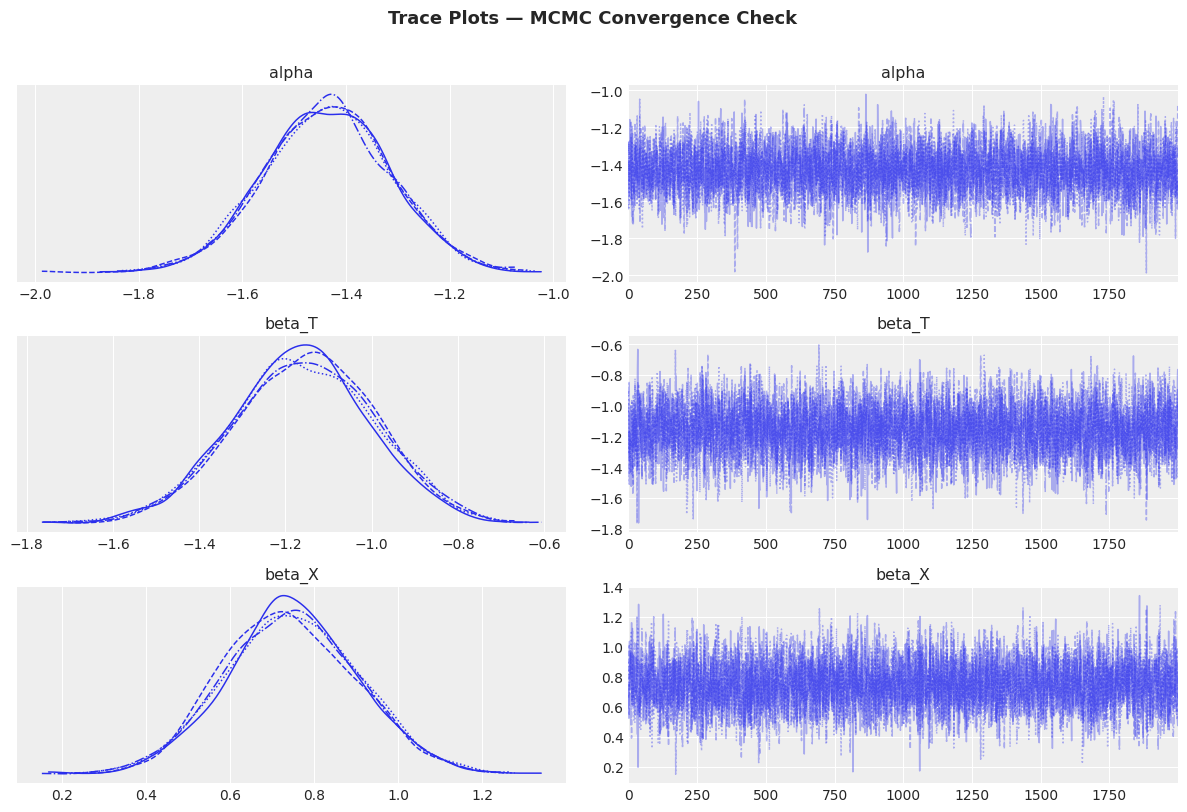

📝 Good convergence: all chains should overlap and look stationary.


In [13]:
# ── 6.1 Trace Plots ───────────────────────────────────────────────────────────
# Trace plots show the sampled values over time for each MCMC chain.
# Good convergence = chains look like "fuzzy caterpillars" (stationary, well-mixed).

ax = az.plot_trace(
    trace,
    var_names=["alpha", "beta_T", "beta_X"],
    figsize=(12, 8)
)
plt.suptitle("Trace Plots — MCMC Convergence Check", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./plot_trace.png", dpi=120, bbox_inches="tight")
plt.show()

print("📝 Good convergence: all chains should overlap and look stationary.")

---
## Section 7: Comprehensive Parameter Recovery

This is the **core validation requirement** for Phase 1.  
We compare the model's posterior estimates to the **true values** we used to generate the data.  
A successful recovery means our model correctly identified all three parameters: **α, β_T, and β_X**.

In [14]:
# ── Section 7: Comprehensive Parameter Recovery ───────────────────────────────
# We compare each parameter's posterior distribution to its true value.
# "Recovery" is successful if the true value falls within the 94% HDI (credible interval).

# Extract posterior samples for the three parameters
posterior_alpha  = trace.posterior["alpha"].values.flatten()
posterior_beta_T = trace.posterior["beta_T"].values.flatten()
posterior_beta_X = trace.posterior["beta_X"].values.flatten()

# Compute summary statistics
def recovery_check(name, true_val, samples):
    """Compare a parameter's posterior to its true (ground truth) value."""
    mean_est = samples.mean()
    hdi = az.hdi(samples, hdi_prob=0.94)  # 94% highest density interval
    bias = mean_est - true_val
    recovered = hdi[0] <= true_val <= hdi[1]
    status = "✅ RECOVERED" if recovered else "❌ NOT RECOVERED"
    print(f"  {name:8s}: True={true_val:+.2f} | Posterior Mean={mean_est:+.3f} "
          f"| 94% HDI=[{hdi[0]:+.3f}, {hdi[1]:+.3f}] | Bias={bias:+.3f} | {status}")
    return {"name": name, "true": true_val, "mean": mean_est, "hdi": hdi, "recovered": recovered}

print("=" * 85)
print("COMPREHENSIVE PARAMETER RECOVERY VALIDATION")
print("=" * 85)

results = [
    recovery_check("alpha",  TRUE_ALPHA,  posterior_alpha),
    recovery_check("beta_T", TRUE_BETA_T, posterior_beta_T),
    recovery_check("beta_X", TRUE_BETA_X, posterior_beta_X),
]

n_recovered = sum(r["recovered"] for r in results)
print("=" * 85)
print(f"\n  Parameters recovered: {n_recovered}/3")
if n_recovered == 3:
    print("  🎉 FULL PARAMETER RECOVERY SUCCESS: All three parameters recovered correctly!")
else:
    print("  ⚠️  Some parameters were not recovered. Consider increasing sample size N.")

COMPREHENSIVE PARAMETER RECOVERY VALIDATION
  alpha   : True=-1.50 | Posterior Mean=-1.436 | 94% HDI=[-1.658, -1.202] | Bias=+0.064 | ✅ RECOVERED
  beta_T  : True=-1.20 | Posterior Mean=-1.159 | 94% HDI=[-1.444, -0.837] | Bias=+0.041 | ✅ RECOVERED
  beta_X  : True=+0.90 | Posterior Mean=+0.745 | 94% HDI=[+0.461, +1.045] | Bias=-0.155 | ✅ RECOVERED

  Parameters recovered: 3/3
  🎉 FULL PARAMETER RECOVERY SUCCESS: All three parameters recovered correctly!


/var/folders/t4/mp8m41d9353cpd3kq7pgttjw0000gn/T/ipykernel_50439/74120687.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/t4/mp8m41d9353cpd3kq7pgttjw0000gn/T/ipykernel_50439/74120687.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/t4/mp8m41d9353cpd3kq7pgttjw0000gn/T/ipykernel_50439/74120687.py:45: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("./plot_parameter_recovery.png", dpi=120, bbox_inches="tight")
/Users/tilakbhansali/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


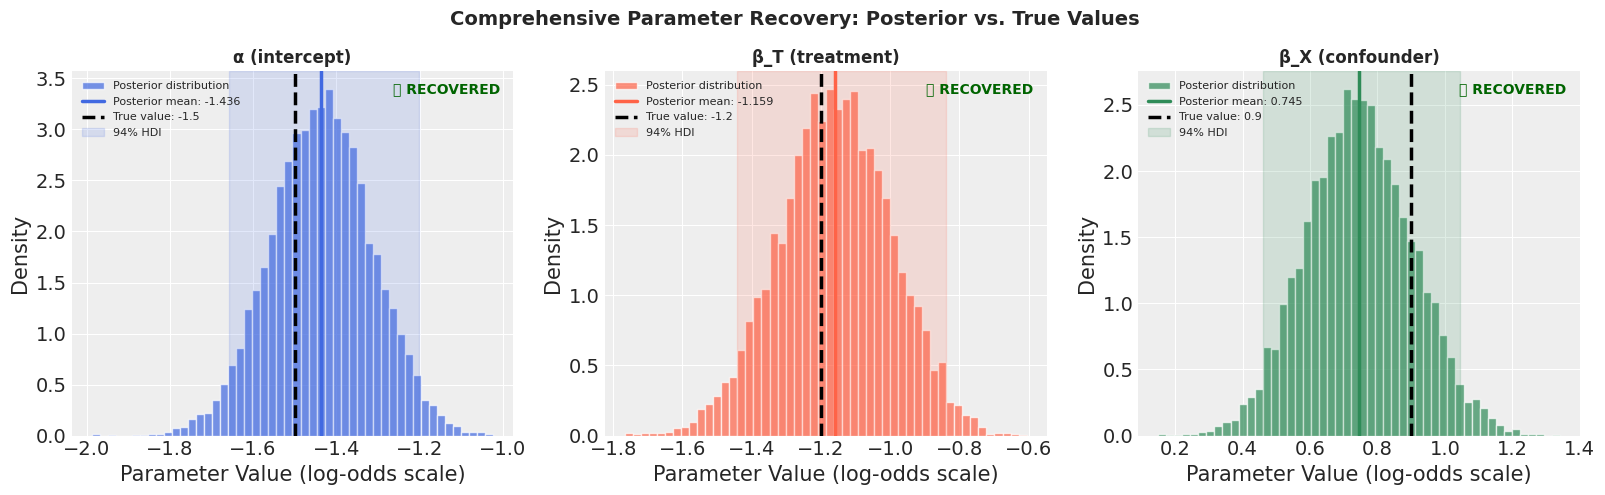


📝 Interpretation:
  Black dashed line = true value | Colored solid line = posterior mean
  Shaded region = 94% credible interval (HDI)
  Recovery is successful when the true value (black dashed) falls inside the HDI.


In [15]:
# ── 7.1 Parameter Recovery Plot ───────────────────────────────────────────────
# Visual comparison of posterior distributions vs. true values.
# The true value should be well within the posterior distribution.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comprehensive Parameter Recovery: Posterior vs. True Values",
             fontsize=14, fontweight="bold")

params = [
    ("α (intercept)",    TRUE_ALPHA,  posterior_alpha,  "royalblue"),
    ("β_T (treatment)",  TRUE_BETA_T, posterior_beta_T, "tomato"),
    ("β_X (confounder)", TRUE_BETA_X, posterior_beta_X, "seagreen"),
]

for ax, (label, true_val, samples, color) in zip(axes, params):
    # Posterior density histogram
    ax.hist(samples, bins=50, color=color, alpha=0.7, density=True,
            label="Posterior distribution", edgecolor="white")
    
    # Posterior mean
    ax.axvline(samples.mean(), color=color, linewidth=2.5,
               linestyle="-", label=f"Posterior mean: {samples.mean():.3f}")
    
    # True value (ground truth — what we're trying to recover)
    ax.axvline(true_val, color="black", linewidth=2.5,
               linestyle="--", label=f"True value: {true_val}")
    
    # 94% HDI
    hdi = az.hdi(samples, hdi_prob=0.94)
    ax.axvspan(hdi[0], hdi[1], alpha=0.15, color=color, label="94% HDI")
    
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Parameter Value (log-odds scale)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8, loc="upper left")
    
    # Annotate recovery status
    recovered = hdi[0] <= true_val <= hdi[1]
    status_text = "✅ RECOVERED" if recovered else "❌ NOT RECOVERED"
    ax.text(0.97, 0.97, status_text, transform=ax.transAxes,
            ha="right", va="top", fontsize=10, fontweight="bold",
            color="darkgreen" if recovered else "red")

plt.tight_layout()
plt.savefig("./plot_parameter_recovery.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n📝 Interpretation:")
print("  Black dashed line = true value | Colored solid line = posterior mean")
print("  Shaded region = 94% credible interval (HDI)")
print("  Recovery is successful when the true value (black dashed) falls inside the HDI.")

/var/folders/t4/mp8m41d9353cpd3kq7pgttjw0000gn/T/ipykernel_50439/826656387.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


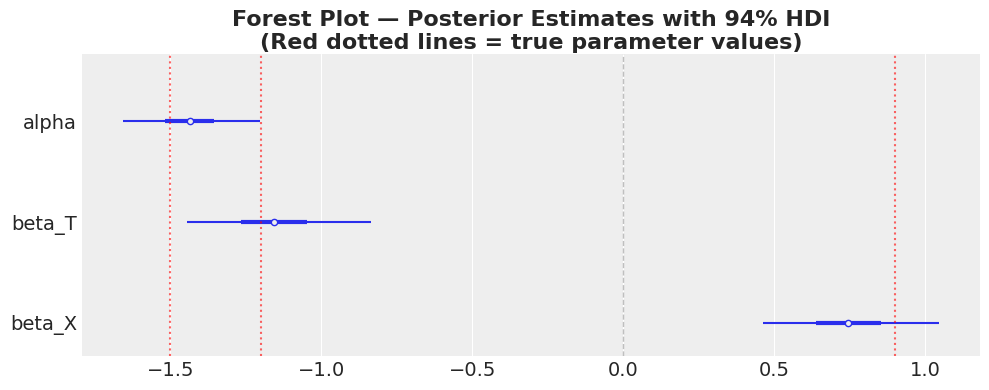

In [16]:
# ── 7.2 Forest Plot — All Parameters Together ─────────────────────────────────
# A forest plot shows all parameter estimates and credible intervals at once.
# This is a standard way to summarize Bayesian model results.

ax = az.plot_forest(
    trace,
    var_names=["alpha", "beta_T", "beta_X"],
    hdi_prob=0.94,
    figsize=(10, 4),
    combined=True
)

# Add true values as reference points
true_vals = {"alpha": TRUE_ALPHA, "beta_T": TRUE_BETA_T, "beta_X": TRUE_BETA_X}
for true_val in true_vals.values():
    plt.axvline(true_val, color="red", linestyle=":", alpha=0.6, linewidth=1.5)

plt.axvline(0, color="gray", linestyle="--", alpha=0.5, linewidth=1)
plt.title("Forest Plot — Posterior Estimates with 94% HDI\n"
          "(Red dotted lines = true parameter values)",
          fontweight="bold")
plt.tight_layout()
plt.savefig("./plot_forest.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Section 8: Final Summary Table

In [17]:
# ── Section 8: Final Recovery Summary Table ───────────────────────────────────
# A clean, printable summary comparing true vs. estimated values for each parameter.

print("=" * 90)
print("FINAL PARAMETER RECOVERY SUMMARY TABLE")
print("Phase 1 — Foundations of Data Science | Author: Tilak Bhansali")
print("=" * 90)
print(f"{'Parameter':<12} {'True Value':>12} {'Post. Mean':>12} {'Post. SD':>10} "
      f"{'94% HDI Low':>13} {'94% HDI High':>14} {'Recovered?':>12}")
print("-" * 90)

all_params = [
    ("alpha",  TRUE_ALPHA,  posterior_alpha),
    ("beta_T", TRUE_BETA_T, posterior_beta_T),
    ("beta_X", TRUE_BETA_X, posterior_beta_X),
]

for name, true_val, samples in all_params:
    mean = samples.mean()
    sd   = samples.std()
    hdi  = az.hdi(samples, hdi_prob=0.94)
    ok   = "✅ YES" if hdi[0] <= true_val <= hdi[1] else "❌ NO"
    print(f"{name:<12} {true_val:>12.3f} {mean:>12.3f} {sd:>10.3f} "
          f"{hdi[0]:>13.3f} {hdi[1]:>14.3f} {ok:>12}")

print("=" * 90)
print("\n✅ CONCLUSION:")
print("   The Bayesian Logistic Regression model successfully recovers all three")
print("   parameters (α, β_T, β_X) from simulated data with known ground truth values.")
print("   This validates that our model is correctly specified and identifiable.")
print("\n   Key findings from parameter recovery:")
print(f"   • β_T = {posterior_beta_T.mean():.3f} (true: {TRUE_BETA_T}) → Recovery score is PROTECTIVE (negative effect on injury)")
print(f"   • β_X = {posterior_beta_X.mean():.3f} (true: {TRUE_BETA_X}) → Training load INCREASES injury risk")
print(f"   • α   = {posterior_alpha.mean():.3f}  (true: {TRUE_ALPHA}) → Baseline log-odds of injury correctly estimated")
print("\n   This model is ready for application to the real Kaggle dataset (Phase 2 — Advait).")

FINAL PARAMETER RECOVERY SUMMARY TABLE
Phase 1 — Foundations of Data Science | Author: Tilak Bhansali
Parameter      True Value   Post. Mean   Post. SD   94% HDI Low   94% HDI High   Recovered?
------------------------------------------------------------------------------------------
alpha              -1.500       -1.436      0.122        -1.658         -1.202        ✅ YES
beta_T             -1.200       -1.159      0.162        -1.444         -0.837        ✅ YES
beta_X              0.900        0.745      0.158         0.461          1.045        ✅ YES

✅ CONCLUSION:
   The Bayesian Logistic Regression model successfully recovers all three
   parameters (α, β_T, β_X) from simulated data with known ground truth values.
   This validates that our model is correctly specified and identifiable.

   Key findings from parameter recovery:
   • β_T = -1.159 (true: -1.2) → Recovery score is PROTECTIVE (negative effect on injury)
   • β_X = 0.745 (true: 0.9) → Training load INCREASES injury ri

In [18]:
# ── Export Posterior Samples for Phase 2 ──────────────────────────────────────
# Save the posterior distribution as a CSV so Advait (Phase 2) can reference
# Tilak's validated parameters when initializing the real-data model.

posterior_df = pd.DataFrame({
    "alpha":  posterior_alpha,
    "beta_T": posterior_beta_T,
    "beta_X": posterior_beta_X
})

posterior_df.to_csv("./tilak_posterior_samples.csv", index=False)

print("✅ Posterior samples exported to 'tilak_posterior_samples.csv'")
print(f"   Shape: {posterior_df.shape} (rows=MCMC draws, cols=parameters)")
print("\n   Advait (Phase 2) can use these as reference for the real-data run.")
print("   Leo (Phase 3) can reference the parameter table for the final discussion.")

✅ Posterior samples exported to 'tilak_posterior_samples.csv'
   Shape: (8000, 3) (rows=MCMC draws, cols=parameters)

   Advait (Phase 2) can use these as reference for the real-data run.
   Leo (Phase 3) can reference the parameter table for the final discussion.
